/tmp/ipykernel_4869/2129340594.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(plot_df))


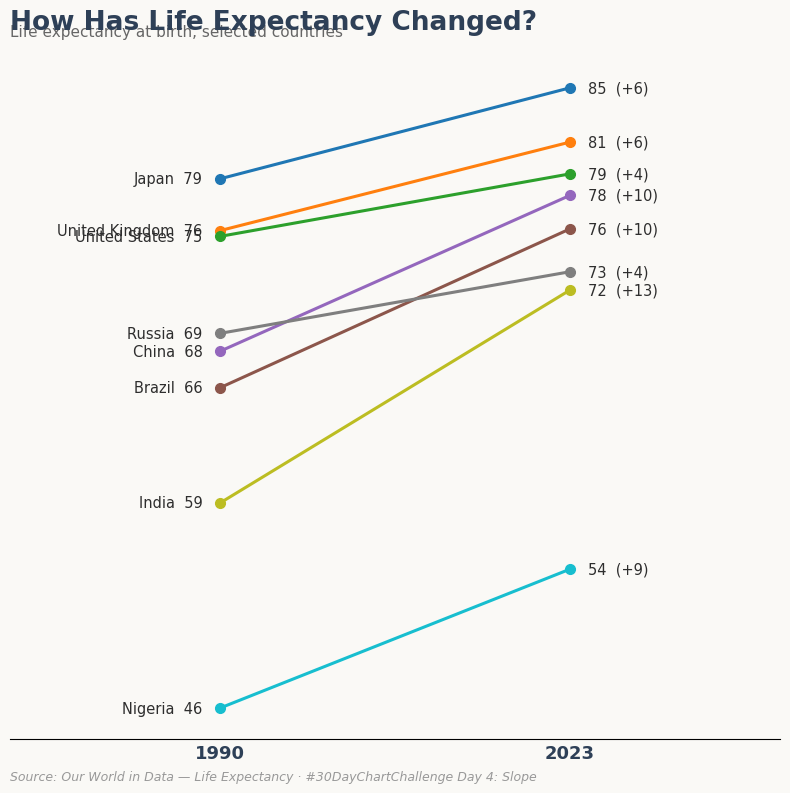

In [1]:
"""
#30DayChartChallenge — Day 4: Slope
"How has life expectancy changed?" — a slope chart comparing life
expectancy at birth in a start year vs. the most recent year available,
for a set of countries.

Data source (loaded live, no hardcoded values):
Our World in Data — Life expectancy (HMD/UN WPP combined series)
https://ourworldindata.org/life-expectancy

Slope charts are ideal for showing "before vs. after" change across a
handful of categories: each category gets one line running from its
value at time A (left) to its value at time B (right). The STEEPNESS
and DIRECTION of the line tell the story at a glance.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. CONFIG — change the country list or start year freely
# ---------------------------------------------------------------------------
COUNTRIES = [
    "United States", "United Kingdom", "China", "India",
    "Nigeria", "Brazil", "Russia", "Japan",
]
YEAR_START = 1990
YEAR_END = None  # None = automatically use the most recent year available

DATA_URL = "https://ourworldindata.org/grapher/life-expectancy-hmd-unwpp.csv?v=1&csvType=full&useColumnShortNames=false"

# ---------------------------------------------------------------------------
# 2. LOAD DATA DIRECTLY FROM SOURCE
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_URL, storage_options={"User-Agent": "Mozilla/5.0"})
value_col = [c for c in df.columns if c not in ("Entity", "Code", "Year")][0]
df = df.rename(columns={value_col: "life_expectancy"})

if YEAR_END is None:
    YEAR_END = int(df[df["Entity"].isin(COUNTRIES)]["Year"].max())

# ---------------------------------------------------------------------------
# 3. BUILD START/END PAIRS FOR EACH COUNTRY
# ---------------------------------------------------------------------------
records = []
for country in COUNTRIES:
    sub = df[df["Entity"] == country]
    start_row = sub[sub["Year"] == YEAR_START]
    end_row = sub[sub["Year"] == YEAR_END]
    if start_row.empty or end_row.empty:
        print(f"Skipping {country}: missing data for {YEAR_START} or {YEAR_END}")
        continue
    records.append({
        "country": country,
        "start": start_row["life_expectancy"].values[0],
        "end": end_row["life_expectancy"].values[0],
    })

plot_df = pd.DataFrame(records).sort_values("end", ascending=False).reset_index(drop=True)

# ---------------------------------------------------------------------------
# 4. PLOT — slope chart
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), facecolor="#FAF9F6")
ax.set_facecolor("#FAF9F6")

palette = plt.cm.get_cmap("tab10", len(plot_df))

for i, row in plot_df.iterrows():
    color = palette(i)
    ax.plot([0, 1], [row["start"], row["end"]], marker="o", markersize=7,
             color=color, linewidth=2.2, solid_capstyle="round", zorder=3)

    # Label at the left (country + start value)
    ax.text(-0.05, row["start"], f"{row['country']}  {row['start']:.0f}",
             ha="right", va="center", fontsize=10.5, color="#2E2E2E")
    # Label at the right (end value + change)
    delta = row["end"] - row["start"]
    sign = "+" if delta >= 0 else ""
    ax.text(1.05, row["end"], f"{row['end']:.0f}  ({sign}{delta:.0f})",
             ha="left", va="center", fontsize=10.5, color="#2E2E2E")

ax.set_xlim(-0.6, 1.6)
ax.set_xticks([0, 1])
ax.set_xticklabels([str(YEAR_START), str(YEAR_END)], fontsize=13, fontweight="bold", color="#2E4057")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_yticks([])
ax.tick_params(axis="x", length=0)

ax.set_title(
    "How Has Life Expectancy Changed?",
    fontsize=19, fontweight="bold", color="#2E4057", pad=20, loc="left",
)
ax.text(
    0, 1.03, "Life expectancy at birth, selected countries",
    fontsize=11, color="#666666", ha="left", transform=ax.transAxes,
)
ax.text(
    0, -0.06, "Source: Our World in Data — Life Expectancy · #30DayChartChallenge Day 4: Slope",
    fontsize=9, color="#999999", ha="left", transform=ax.transAxes, style="italic",
)

plt.tight_layout()
plt.savefig("day4_slope.png", dpi=200, facecolor="#FAF9F6", bbox_inches="tight")
plt.show()